<a href="https://colab.research.google.com/github/anuja-kotnala/FingerPrint_Matching/blob/main/fingerprint_matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fingerprint Matching using ORB Feature Descriptor
Verifies whether two fingerprint images belong to the same person using OpenCV's ORB detector and Brute Force Matcher.

In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import os

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:

uploaded = files.upload()

import zipfile
for fname in uploaded.keys():
    with zipfile.ZipFile(fname, 'r') as z:
        z.extractall('/content/fvc2002')
print('Dataset extracted!')
print(os.listdir('/content/fvc2002'))

Saving fingerPrints.zip to fingerPrints.zip
Dataset extracted!
['fingerprints']


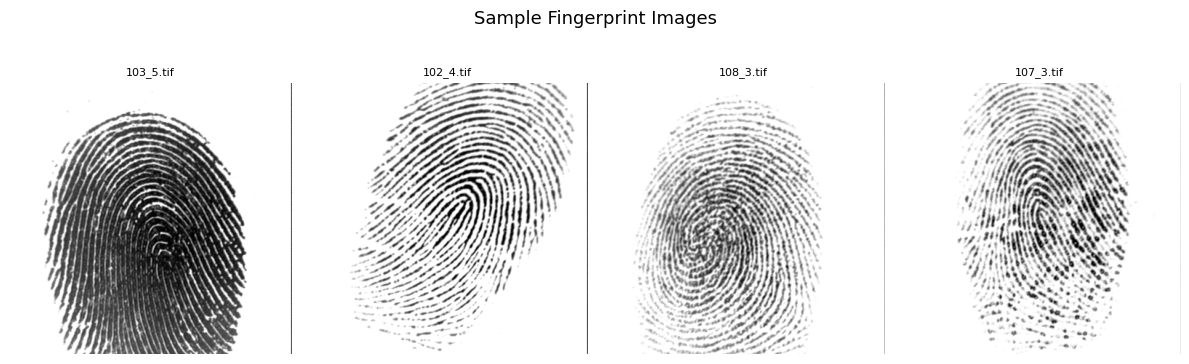

In [16]:
# Step 3 — Sample Fingerprints

dataset_path = '/content/fvc2002/fingerprints/DB1_B'

def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f'Could not load image: {path}')
    return img

# Display 4 sample fingerprints
samples = [f for f in os.listdir(dataset_path) if f.endswith('.tif')][:4]
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for ax, fname in zip(axes, samples):
    img = load_image(os.path.join(dataset_path, fname))
    ax.imshow(img, cmap='gray')
    ax.set_title(fname, fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Fingerprint Images', fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
# Step 4 — Core Matching Function using ORB + Brute Force Matcher
def match_fingerprints(img1_path, img2_path, threshold=50, show=True):
    img1 = load_image(img1_path)
    img2 = load_image(img2_path)

    # ORB detector — finds keypoints and descriptors
    orb = cv2.ORB_create(nfeatures=500)
    kp1, des1 = orb.detectAndCompute(img1, None)
    kp2, des2 = orb.detectAndCompute(img2, None)

    if des1 is None or des2 is None:
        return False, 0

    # Brute Force Matcher
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    # Keep only good matches (low distance = better match)
    good_matches = [m for m in matches if m.distance < 60]
    score = len(good_matches)
    is_match = score >= threshold

    if show:
        match_img = cv2.drawMatches(img1, kp1, img2, kp2,
                                     good_matches[:20], None,
                                     flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
        plt.figure(figsize=(14, 5))
        plt.imshow(match_img, cmap='gray')
        result = 'MATCH' if is_match else 'NO MATCH'
        plt.title(f'{result}  |  Good Matches: {score}  |  Threshold: {threshold}', fontsize=13)
        plt.axis('off')
        plt.tight_layout()
        plt.savefig('match_result.png', dpi=150)
        plt.show()

    return is_match, score

print('Matching function defined!')

Matching function defined!


/tmp/ipykernel_6740/3946497249.py:33: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6740/3946497249.py:34: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('match_result.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


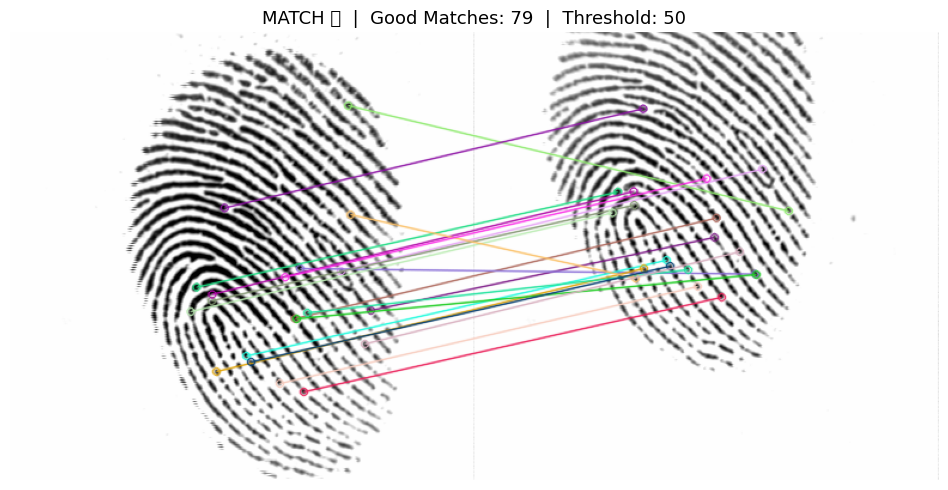

Same person test → Match: True, Score: 79


In [18]:
# Person 101, Sample 1 vs Sample 2 — same person, different impression
img1 = os.path.join(dataset_path, '101_1.tif')
img2 = os.path.join(dataset_path, '101_2.tif')

result, score = match_fingerprints(img1, img2, threshold=50)
print(f'Same person test → Match: {result}, Score: {score}')

/tmp/ipykernel_6740/3946497249.py:33: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6740/3946497249.py:34: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('match_result.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


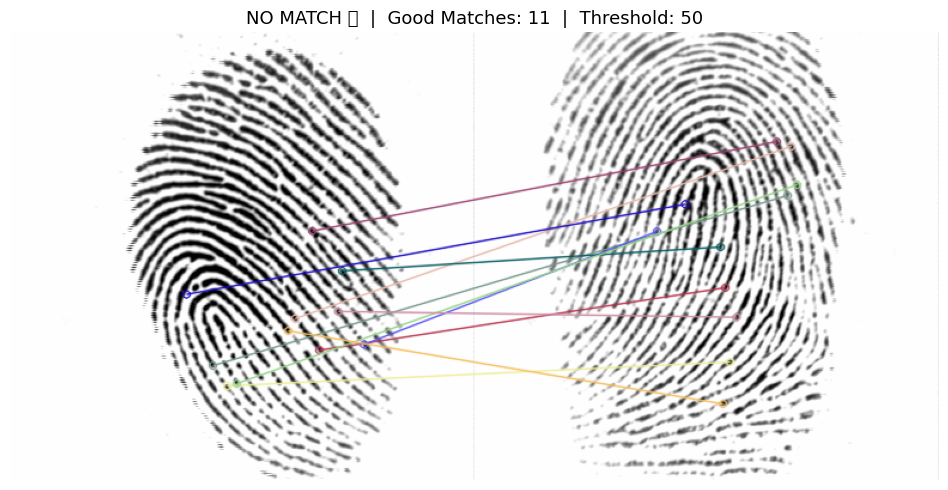

Different person test → Match: False, Score: 11


In [19]:
# Person 101 vs Person 102 — different people
img1 = os.path.join(dataset_path, '101_1.tif')
img2 = os.path.join(dataset_path, '102_1.tif')

result, score = match_fingerprints(img1, img2, threshold=50)
print(f'Different person test → Match: {result}, Score: {score}')

Evaluating genuine pairs...
Evaluating impostor pairs...

Accuracy: 62.50%


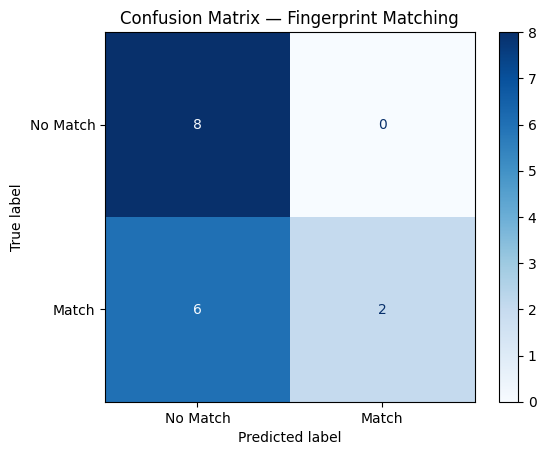

In [20]:
#Batch Evaluation on Multiple Pairs


genuine_pairs = [
    ('101_1.tif', '101_2.tif'), ('101_1.tif', '101_3.tif'),
    ('102_1.tif', '102_2.tif'), ('102_1.tif', '102_3.tif'),
    ('103_1.tif', '103_2.tif'), ('103_1.tif', '103_3.tif'),
    ('104_1.tif', '104_2.tif'), ('105_1.tif', '105_2.tif'),
]

impostor_pairs = [
    ('101_1.tif', '102_1.tif'), ('101_1.tif', '103_1.tif'),
    ('102_1.tif', '103_1.tif'), ('103_1.tif', '104_1.tif'),
    ('104_1.tif', '105_1.tif'), ('105_1.tif', '106_1.tif'),
    ('101_2.tif', '103_2.tif'), ('102_2.tif', '104_2.tif'),
]

y_true, y_pred = [], []

print('Evaluating genuine pairs...')
for f1, f2 in genuine_pairs:
    p1 = os.path.join(dataset_path, f1)
    p2 = os.path.join(dataset_path, f2)
    if os.path.exists(p1) and os.path.exists(p2):
        result, _ = match_fingerprints(p1, p2, threshold=50, show=False)
        y_true.append(1)
        y_pred.append(1 if result else 0)

print('Evaluating impostor pairs...')
for f1, f2 in impostor_pairs:
    p1 = os.path.join(dataset_path, f1)
    p2 = os.path.join(dataset_path, f2)
    if os.path.exists(p1) and os.path.exists(p2):
        result, _ = match_fingerprints(p1, p2, threshold=50, show=False)
        y_true.append(0)
        y_pred.append(1 if result else 0)

acc = accuracy_score(y_true, y_pred)
print(f'\nAccuracy: {acc * 100:.2f}%')

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Match', 'Match'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Fingerprint Matching')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()